In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
from pathlib import Path
import sys  

# Get my_package directory path from Notebook
parent_dir = str(Path().resolve().parents[0])

# Add to sys.path
sys.path.insert(0, parent_dir)


In [3]:
from utils.experiment_utils import get_all_experiments_info, load_best_model

device = 'cuda'
configs = get_all_experiments_info('../outputs/', False)
cfgs = [
    c for c in configs if 'mnist' in c['name'] 
    if 'n_unique_sets' in c['config']['dataset']
    and c['config']['dataset']['n_unique_sets'] == 10000
    # and c['encoder'] == 'ConvDistributionEncoder'
    # and c['config']['training']['num_epochs'] == 1000
]   



In [4]:
cfgs

[{'name': 'mnist_colors_exp_f81473cc9675a3108aadc51f0068a7a8',
  'dir': '../outputs/mnist_colors_exp_f81473cc9675a3108aadc51f0068a7a8',
  'config': {'dataset': {'_target_': 'datasets.mnist_colors.MNISTColorsDataset', 'n_sets': 50000, 'set_size': '${experiment.set_size}', 'data_shape': [3, 28, 28], 'digit_class': None, 'seed': '${seed}', 'data_root': './data', 'train': True, 'n_unique_sets': 10000}, 'encoder': {'_target_': 'encoder.conv_gnn.ConvDistributionEncoder', 'in_channels': '${dataset.data_shape[0]}', 'hidden_channels': 64, 'out_channels': 32, 'hidden_dim': '${experiment.hidden_dim}', 'latent_dim': '${experiment.latent_dim}', 'num_layers': 3, 'kernel_size': 3, 'height': '${dataset.data_shape[1]}', 'width': '${dataset.data_shape[2]}', 'pool_type': 'mean', 'agg_type': 'mean'}, 'model': {'_target_': 'model.unet.ContextUnet', 'in_channels': 3, 'n_feat': 64, 'latent_dim': 64, 'image_size': 28}, 'coupling': {'_target_': 'types.NoneType'}, 'generator': {'_target_': 'generator.flow_match

In [5]:
import hydra
# load + prep dataset
def prepare_dataset(dataset_cfg):
    # probs = np.column_stack((np.linspace(0, 1, num_probs), 1 - np.linspace(0, 1, num_probs)))
    dataset = hydra.utils.instantiate(dataset_cfg)
    # dataset.probs = probs
    # dataset.data, _, _ = dataset.make_sets()
    return dataset

# load encoder and move to device
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

enc, gen = load_model(cfgs[0]['config'], cfgs[0]['dir'], device)

In [6]:
ds = prepare_dataset(cfgs[0]['config']['dataset'])

In [7]:
batch = next(iter(ds))

In [8]:
import numpy as np
import torch
source_samples = batch['source_samples']
target_samples = batch['target_samples']
source_latent, target_latent = enc(
    torch.from_numpy(np.concatenate([source_samples[None, ...], target_samples[None, ...]], axis=0)).float().to(device)
)

resample = gen.sample(source_samples.to(device), source_latent.unsqueeze(0), target_latent.unsqueeze(0)).squeeze()

In [9]:
gen

FlowMatchingGenerator(
  (model): ContextUnet(
    (init_conv): ResidualConvBlock(
      (conv1): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
      )
      (conv2): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
      )
    )
    (down1): UnetDown(
      (model): Sequential(
        (0): ResidualConvBlock(
          (conv1): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): GELU(approximate='none')
          )
          (conv2): Sequential(
            (0): Conv2d(64, 64, kernel_size=

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.41580787..1.0113329].


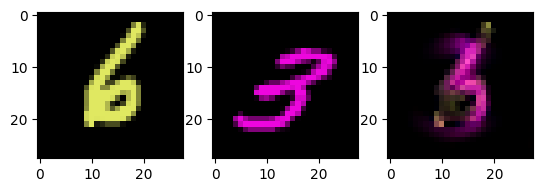

In [15]:
import matplotlib.pyplot as plt
# visualize 3 channel image
source_samples = batch['source_samples']
target_samples = batch['target_samples']
i = 29
fig, axs = plt.subplots(1, 3)
axs[0].imshow(source_samples[i].cpu().numpy().transpose(1, 2, 0))
axs[1].imshow(target_samples[i].cpu().numpy().transpose(1, 2, 0))
axs[2].imshow(resample[i].cpu().numpy().transpose(1, 2, 0))
plt.show()

In [20]:
import torch
import numpy as np
mnist_images = []
for mnist_idx in ds.digit_indices[5]:
    mnist_img, _ = ds.mnist_dataset[mnist_idx]
    mnist_images.append(mnist_img)

# Stack into batch tensor: (set_size, 1, 28, 28)
mnist_images = torch.stack(mnist_images)

In [ ]:
color = torch.rand(3)
cimgs = ds._apply_color_transform(mnist_images, color)



OutOfMemoryError: CUDA out of memory. Tried to allocate 1.01 GiB. GPU 0 has a total capacity of 79.10 GiB of which 1.00 GiB is free. Including non-PyTorch memory, this process has 680.00 MiB memory in use. Process 3751050 has 77.42 GiB memory in use. Of the allocated memory 151.50 MiB is allocated by PyTorch, and 12.50 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [35]:
colors, embeddings = [], []
with torch.no_grad():
    for _ in range(10_000):
        color = torch.rand(3)
        colors.append(color)
        cimgs = ds._apply_color_transform(mnist_images, color)

        e = enc(cimgs.unsqueeze(0).float().cuda()).detach().cpu().numpy()
        embeddings.append(e)


KeyboardInterrupt: 

In [49]:
embeddings = embeddings.reshape(-1, 64)
colors = colors.reshape(-1, 3)

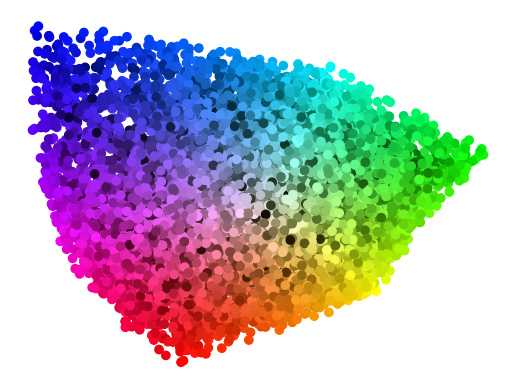

In [51]:
from sklearn.decomposition import PCA
# pca of embeddings
# embeddings = np.concatenate(embeddings, axis=0)
# colors = np.concatenate(colors, axis=0)
pca = PCA(n_components=2)
pca.fit(embeddings)
embeddings_pca = pca.transform(embeddings)


# plot embeddings_pca, colored by colors
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=colors)
# turn off axis
plt.axis('off')
plt.show()
